In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("data/transit_ridership.csv")
df.head

<bound method NDFrame.head of             date route_id direction  boarding_count  alighting_count  \
0     2024-10-21     R205   Inbound           388.0             57.0   
1     2024-08-29     R105  Outbound           457.0            169.0   
2     2024-08-31     R207   Inbound             NaN            518.0   
3     2024-12-24     R208  Outbound           354.0            302.0   
4     2024-03-05     R207   Inbound           423.0            643.0   
...          ...      ...       ...             ...              ...   
1988  2024-07-07     R104   Inbound           216.0            599.0   
1989  2024-06-11     R104  Outbound            41.0            464.0   
1990  2024-09-29     R205  Outbound           103.0            413.0   
1991  2024-10-21     R206   Inbound           139.0            623.0   
1992  2024-11-12     R302  Outbound           745.0            677.0   

         vehicle_type  trip_duration_min   weather  temperature_c is_holiday  
0             Minibus     

In [20]:
df.shape

(1993, 10)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1993 non-null   str    
 1   route_id           1993 non-null   str    
 2   direction          1993 non-null   str    
 3   boarding_count     1854 non-null   float64
 4   alighting_count    1907 non-null   float64
 5   vehicle_type       1993 non-null   str    
 6   trip_duration_min  1883 non-null   float64
 7   weather            1993 non-null   str    
 8   temperature_c      1940 non-null   float64
 9   is_holiday         1993 non-null   str    
dtypes: float64(4), str(6)
memory usage: 155.8 KB


In [22]:
unique_number = []
for i in df.columns:
  x = df[i].value_counts().count()
  unique_number.append(x)
pd.DataFrame(unique_number, index=df.columns, columns=["tottal unque value"])

,tottal unque value
date,536
route_id,13
direction,10
boarding_count,706
alighting_count,681
vehicle_type,9
trip_duration_min,686
weather,4
temperature_c,543
is_holiday,8


In [24]:
numeric_var = ["date", "boarding_count", "alighting_count", "trip_duration_min", "temperature_c"]
categorical_var = ["route_id", "direction", "vehicle_type", "weather", "is_holiday"]

df.describe()

,boarding_count,alighting_count,trip_duration_min,temperature_c
count,1854.000000,1907.000000,1883.000000,1940.000000
mean,410.625674,381.549554,56.235582,14.030052
std,222.595905,214.463238,58.949897,16.434646
min,20.000000,15.000000,-12.300000,-15.000000
25%,216.250000,191.500000,32.900000,-0.300000
50%,412.500000,379.000000,52.500000,14.200000
75%,600.000000,565.500000,71.400000,28.500000
max,800.000000,750.000000,999.000000,42.000000


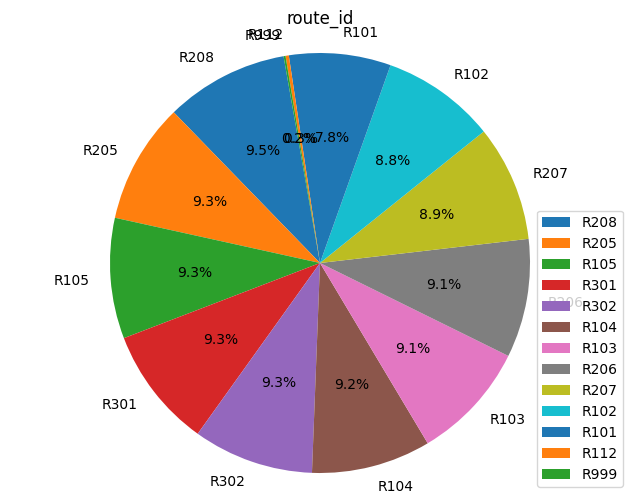

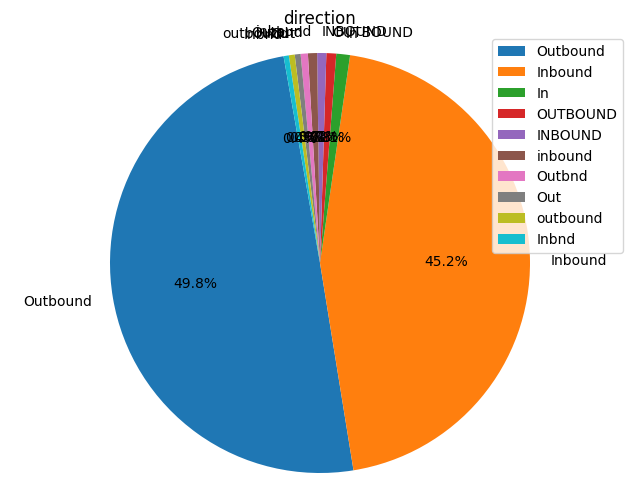

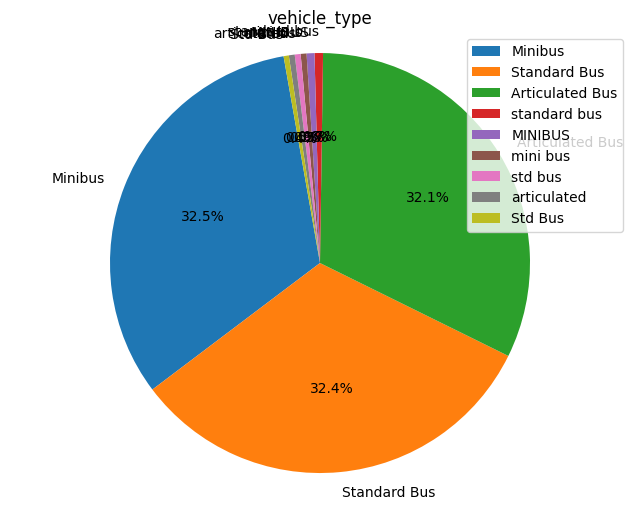

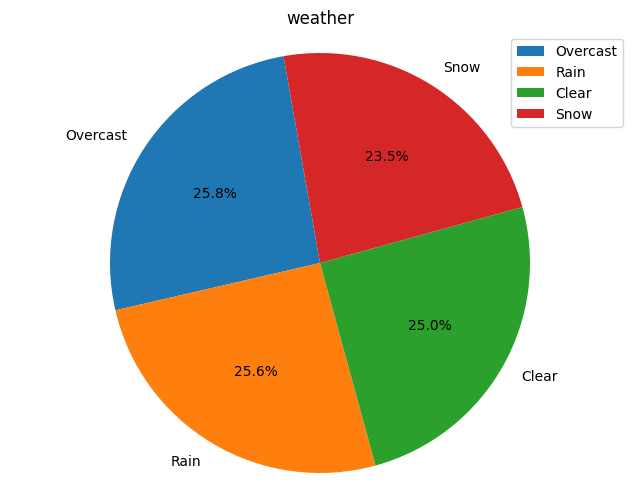

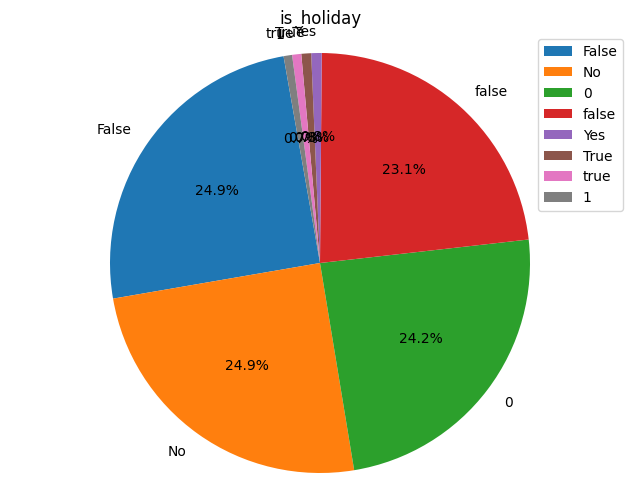

In [26]:
for i in categorical_var:
  fig, ax = plt.subplots(figsize=(8, 6))
  observation_value = list(df[i].value_counts().index)
  total_observation_value = list(df[i].value_counts())
  ax.pie(total_observation_value, labels=observation_value, autopct='%1.1f%%', startangle=100)
  ax.axis('equal')
  plt.title(i)
  plt.legend()
  plt.show()

In [33]:
#توحيد الوقت

def parse_mixed_date(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    for fmt in ("%Y-%m-%d", "%m/%d/%Y", "%d-%b-%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except ValueError:
            continue

    return pd.NaT

df["date"] = df["date"].apply(parse_mixed_date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   date               0 non-null      datetime64[s]
 1   route_id           1993 non-null   str          
 2   direction          1993 non-null   str          
 3   boarding_count     1854 non-null   float64      
 4   alighting_count    1907 non-null   float64      
 5   vehicle_type       1993 non-null   str          
 6   trip_duration_min  1883 non-null   float64      
 7   weather            1993 non-null   str          
 8   temperature_c      1940 non-null   float64      
 9   is_holiday         1993 non-null   str          
dtypes: datetime64[s](1), float64(4), str(5)
memory usage: 155.8 KB


In [ ]:
#remove r999
invalid_routes = ["R999"]
df = df[~df["route_id"].isin(invalid_routes)]

In [36]:
# Clean direction labels into two standard values: Inbound and Outbound.
direction_map = {
    "Inbound": "Inbound",
    "INBOUND": "Inbound",
    "inbound": "Inbound",
    "In": "Inbound",
    "Inbnd": "Inbound",
    "Outbound": "Outbound",
    "OUTBOUND": "Outbound",
    "outbound": "Outbound",
    "Out": "Outbound",
    "Outbnd": "Outbound",
}

df["direction"] = (
    df["direction"]
    .astype(str)
    .str.strip()
    .replace(direction_map)
)

print(df["direction"].value_counts(dropna=False))

direction
Outbound    1034
Inbound      956
Name: count, dtype: int64


In [39]:
# Fill missing boarding_count using grouped medians, starting with the most specific groups.
import pandas as pd

df["boarding_count"] = pd.to_numeric(df["boarding_count"], errors="coerce")

df["boarding_count"] = df["boarding_count"].fillna(
    df.groupby(["route_id", "direction", "vehicle_type", "is_holiday"])["boarding_count"]
      .transform("median")
)

df["boarding_count"] = df["boarding_count"].fillna(
    df.groupby(["route_id", "direction"])["boarding_count"]
      .transform("median")
)

df["boarding_count"] = df["boarding_count"].fillna(
    df.groupby("route_id")["boarding_count"]
      .transform("median")
)

df["boarding_count"] = df["boarding_count"].fillna(df["boarding_count"].median())
df.info()

<class 'pandas.DataFrame'>
Index: 1990 entries, 0 to 1992
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   date               0 non-null      datetime64[s]
 1   route_id           1990 non-null   str          
 2   direction          1990 non-null   str          
 3   boarding_count     1990 non-null   float64      
 4   alighting_count    1904 non-null   float64      
 5   vehicle_type       1990 non-null   str          
 6   trip_duration_min  1880 non-null   float64      
 7   weather            1990 non-null   str          
 8   temperature_c      1937 non-null   float64      
 9   is_holiday         1990 non-null   str          
dtypes: datetime64[s](1), float64(4), str(5)
memory usage: 171.0 KB


In [41]:
# Standardize vehicle type labels into three categories.
vehicle_type_map = {
    "Minibus": "Minibus",
    "MINIBUS": "Minibus",
    "mini bus": "Minibus",

    "Standard Bus": "Standard Bus",
    "standard bus": "Standard Bus",
    "Std Bus": "Standard Bus",
    "std bus": "Standard Bus",

    "Articulated Bus": "Articulated Bus",
    "articulated": "Articulated Bus",
}

df["vehicle_type"] = (
    df["vehicle_type"]
    .astype(str)
    .str.strip()
    .replace(vehicle_type_map)
)

In [45]:
# Clean trip duration by removing impossible values, then fill missing values with grouped medians.
import pandas as pd

df["trip_duration_min"] = pd.to_numeric(df["trip_duration_min"], errors="coerce")

# Mark invalid values as missing
df.loc[
    (df["trip_duration_min"] <= 0) | (df["trip_duration_min"] > 180),
    "trip_duration_min"
] = pd.NA

# Fill missing values using grouped medians
df["trip_duration_min"] = df["trip_duration_min"].fillna(
    df.groupby(["route_id", "direction", "vehicle_type"])["trip_duration_min"]
      .transform("median")
)

# Fallback: broader grouping
df["trip_duration_min"] = df["trip_duration_min"].fillna(
    df.groupby(["route_id", "direction"])["trip_duration_min"]
      .transform("median")
)

# Fallback: route-level median
df["trip_duration_min"] = df["trip_duration_min"].fillna(
    df.groupby("route_id")["trip_duration_min"]
      .transform("median")
)

# Final fallback: overall median
df["trip_duration_min"] = df["trip_duration_min"].fillna(
    df["trip_duration_min"].median()
)
print(df["trip_duration_min"].head(20))

0     77.90
1     76.60
2     58.50
3     47.40
4     17.40
5     54.45
6     21.90
7     59.80
8     38.50
9     60.40
10    55.70
11    49.90
12    48.20
13    35.30
14    30.10
15    38.50
16    78.50
17    46.25
18    54.45
19    59.10
Name: trip_duration_min, dtype: float64


In [47]:
# Fill missing temperatures using date/weather-aware grouped medians.
df["temperature_c"] = pd.to_numeric(df["temperature_c"], errors="coerce")

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract month for seasonal fallback
df["month"] = df["date"].dt.month

# 1) Same date + weather
df["temperature_c"] = df["temperature_c"].fillna(
    df.groupby(["date", "weather"])["temperature_c"].transform("median")
)

# 2) Same month + weather
df["temperature_c"] = df["temperature_c"].fillna(
    df.groupby(["month", "weather"])["temperature_c"].transform("median")
)

# 3) Same month
df["temperature_c"] = df["temperature_c"].fillna(
    df.groupby("month")["temperature_c"].transform("median")
)

# 4) Overall fallback
df["temperature_c"] = df["temperature_c"].fillna(
    df["temperature_c"].median()
)

# Optional cleanup if you do not want to keep helper column
df.drop(columns="month", inplace=True)

In [48]:
# Standardize holiday values and convert them to boolean.
holiday_map = {
    "False": False,
    "false": False,
    "No": False,
    "0": False,
    "True": True,
    "true": True,
    "Yes": True,
    "1": True,
}

df["is_holiday"] = (
    df["is_holiday"]
    .astype(str)
    .str.strip()
    .replace(holiday_map)
    .astype(bool)
)
print(df["is_holiday"].dtype)


bool


In [50]:
# Remove fully duplicated rows.
df = df.drop_duplicates()

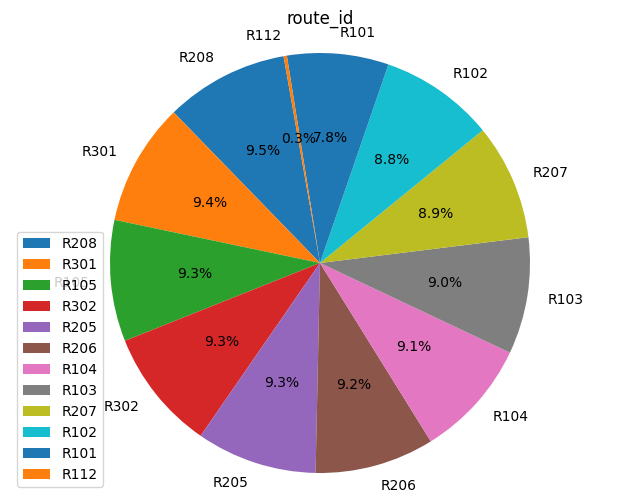

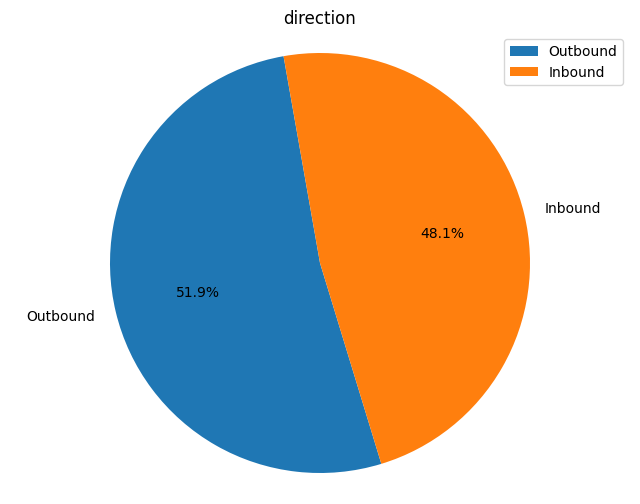

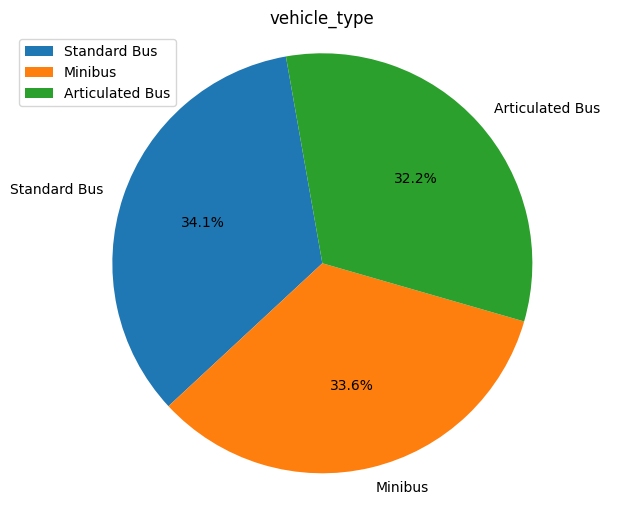

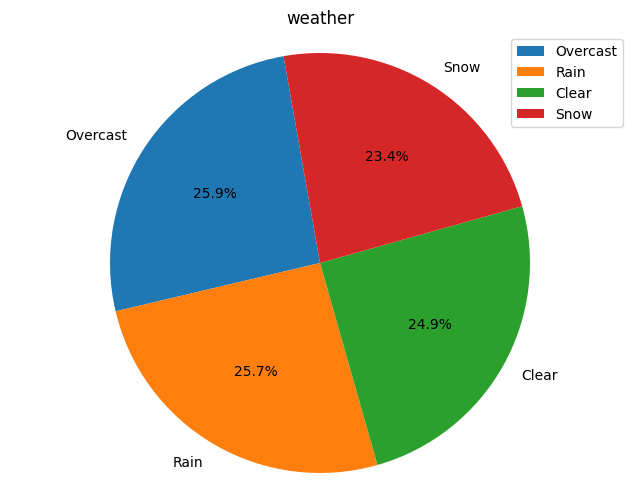

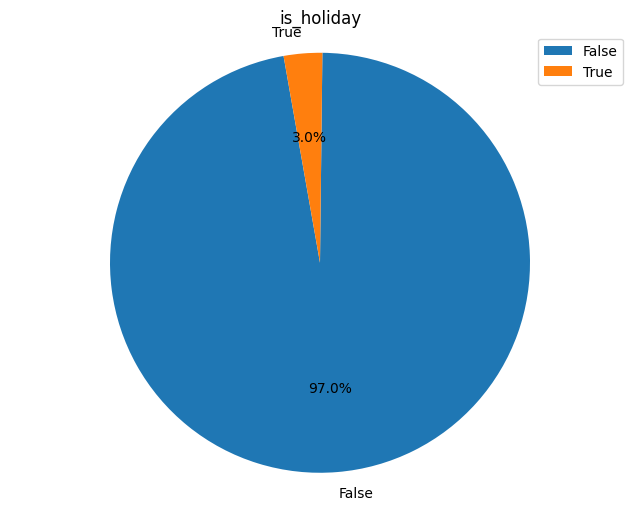

In [52]:
for i in categorical_var:
  fig, ax = plt.subplots(figsize=(8, 6))
  observation_value = list(df[i].value_counts().index)
  total_observation_value = list(df[i].value_counts())
  ax.pie(total_observation_value, labels=observation_value, autopct='%1.1f%%', startangle=100)
  ax.axis('equal')
  plt.title(i)
  plt.legend()
  plt.show()